## Налаштування та завантаження датасету Fashion MNIST

In [15]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np

In [16]:
(train_images, train_labels), (test_images, test_labels) = keras.datasets.fashion_mnist.load_data()

print(f"Розмір навчальних зображень: {train_images.shape}")
print(f"Розмір навчальних міток: {train_labels.shape}")
print(f"Розмір тестових зображень: {test_images.shape}")
print(f"Розмір тестових міток: {test_labels.shape}")

Розмір навчальних зображень: (60000, 28, 28)
Розмір навчальних міток: (60000,)
Розмір тестових зображень: (10000, 28, 28)
Розмір тестових міток: (10000,)


Датасет Fashion MNIST містить 60 000 зображень для навчання та 10 000 зображень для тестування. Кожне зображення є чорно-білим, розміром 28x28 пікселів.

## Перегляд даних

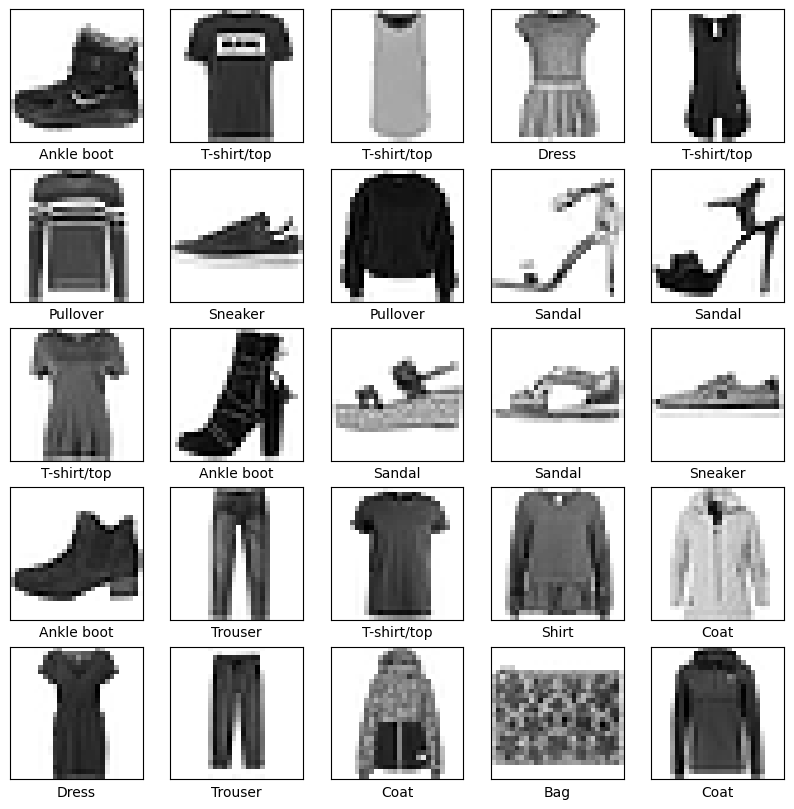

In [17]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()

Ми бачимо, що кожне зображення являє собою окремий предмет одягу, а мітки відповідають типу цього предмета.

## Передобработка даних

In [18]:
train_images = train_images / 255.0
test_images = test_images / 255.0

train_images_flat = train_images.reshape(train_images.shape[0], -1)
test_images_flat = test_images.reshape(test_images.shape[0], -1)

print(f"Розмір нормалізованих та сплощених навчальних зображень: {train_images_flat.shape}")
print(f"Розмір нормалізованих та сплощених тестових зображень: {test_images_flat.shape}")

Розмір нормалізованих та сплощених навчальних зображень: (60000, 784)
Розмір нормалізованих та сплощених тестових зображень: (10000, 784)


Після передобработки наші зображення готові до використання в нейронній мережі.

## Побудова та компіляція моделі

In [19]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_4 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Ми створили просту модель з одним прихованим шаром. Тепер можемо її навчити.

## Навчання моделі

In [20]:
history = model.fit(train_images, train_labels, epochs=10, validation_split=0.2)

test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)
print(f'\nТочність на тестових даних: {test_acc}')

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8216 - loss: 0.5180 - val_accuracy: 0.8481 - val_loss: 0.4293
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8625 - loss: 0.3853 - val_accuracy: 0.8607 - val_loss: 0.3810
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8734 - loss: 0.3477 - val_accuracy: 0.8647 - val_loss: 0.3770
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8813 - loss: 0.3218 - val_accuracy: 0.8783 - val_loss: 0.3523
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8891 - loss: 0.3011 - val_accuracy: 0.8831 - val_loss: 0.3260
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8951 - loss: 0.2847 - val_accuracy: 0.8843 - val_loss: 0.3295
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8984 - loss: 0.2745 - val_accuracy: 0.8800 - val_loss: 0.3337
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9028 - loss: 0.2607 - 

## Аналіз історії навчання

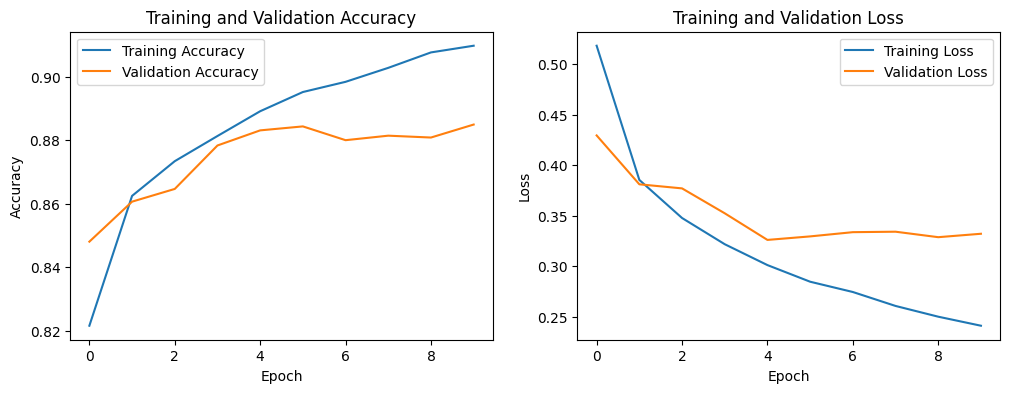

In [21]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')

plt.show()

## Удосконалення моделі: Додавання шару Dropout та збільшення складності

In [22]:
model_improved = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(512, activation='elu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(256, activation='elu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(128, activation='elu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation='softmax')
])

model_improved.compile(optimizer='rmsprop',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

model_improved.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

Ми збільшили кількість нейронів у першому прихованому шарі, додали другий прихований шар і включили шари Dropout для регуляризації. Тепер навчимо цю нову модель.

## Навчання покращеної моделі

In [23]:
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_improved = model_improved.fit(train_images, train_labels, epochs=100, validation_split=0.2, callbacks=[early_stopping])

test_loss_improved, test_acc_improved = model_improved.evaluate(test_images,  test_labels, verbose=2)
print(f'\nТочність покращеної моделі на тестових даних: {test_acc_improved}')

Epoch 1/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7602 - loss: 0.6976 - val_accuracy: 0.8234 - val_loss: 0.4639
Epoch 2/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8212 - loss: 0.5060 - val_accuracy: 0.8534 - val_loss: 0.4313
Epoch 3/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8394 - loss: 0.4632 - val_accuracy: 0.8540 - val_loss: 0.4159
Epoch 4/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8478 - loss: 0.4382 - val_accuracy: 0.8713 - val_loss: 0.4079
Epoch 5/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8520 - loss: 0.4300 - val_accuracy: 0.8702 - val_loss: 0.3699
Epoch 6/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8566 - loss: 0.4244 - val_accuracy: 0.8622 - val_loss: 0.3820
Epoch 7/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8597 - loss: 0.4151 - val_accuracy: 0.8727 - val_loss: 0.3787
Epoch 8/100
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8632 - loss

Модель навчена, і ми отримали її точність на тестових даних. Давайте знову візуалізуємо історію навчання, щоб порівняти її з попередньою моделлю і зробити висновки.

## Аналіз історії навчання покращеної моделі

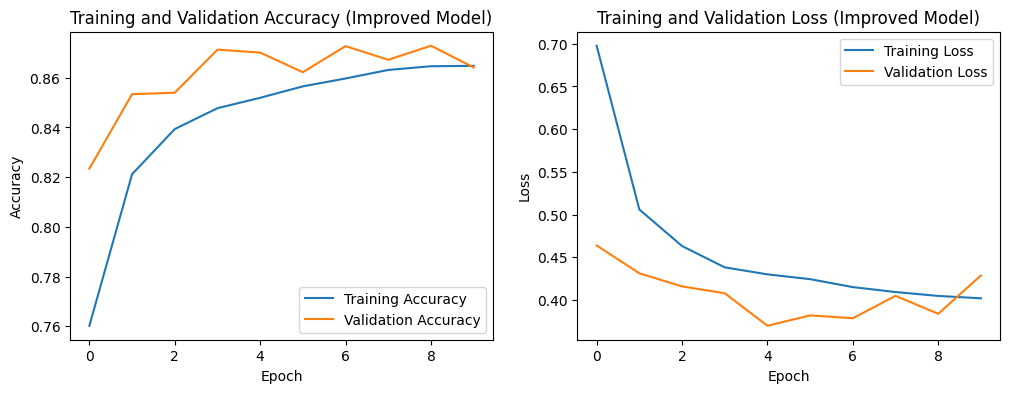

In [24]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_improved.history['accuracy'], label='Training Accuracy')
plt.plot(history_improved.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy (Improved Model)')

plt.subplot(1, 2, 2)
plt.plot(history_improved.history['loss'], label='Training Loss')
plt.plot(history_improved.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss (Improved Model)')

plt.show()

Проаналізувавши ці графіки та отриману точність, ми можемо оцінити, чи допомогли додаткові шари та використання Dropout покращити продуктивність моделі. Якщо точність все ще не досягла бажаних 91%, ми можемо далі експериментувати з іншими гіперпараметрами, такими як кількість нейронів, функції активації, оптимізатори, розмір батчу або збільшити кількість епох.